# Task 2.3 — Result, Comparison, and Reproducibility Checklist (15 marks)

This notebook presents the final results of our reproduction, compares them with the paper's claims, and provides a reproducibility checklist.

In [1]:
import numpy as np
from scipy import stats
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

Standard imports for numerical computation, statistical fitting, clustering, and visualisation.

In [2]:
# ============================================================
# Reproduce the full pipeline from Task 2.2 and collect results
# ============================================================

def generate_simulation_data(N=100, seed=42):
    rng = np.random.RandomState(seed)
    rho_x, rho_y = 0.9, 0.5
    cov_x = np.array([[1, rho_x], [rho_x, 1]])
    cov_y = np.array([[1, rho_y], [rho_y, 1]])
    
    X_c1 = rng.multivariate_normal([0, 0], cov_x, N)
    X_c2 = rng.multivariate_normal([1, 1], cov_x, N)
    view1 = np.vstack([X_c1, X_c2])
    
    def corr_beta(a, b, cov, n, rng):
        Z = rng.multivariate_normal([0, 0], cov, n)
        U = stats.norm.cdf(Z)
        return stats.beta.ppf(U, a, b)
    
    Y_c1 = corr_beta(3, 1, cov_y, N, rng)
    Y_c2 = corr_beta(1, 10, cov_y, N, rng)
    view2 = np.vstack([Y_c1, Y_c2])
    labels = np.array([0]*N + [1]*N)
    return view1, view2, labels

def run_experiment(N=100, seed=42):
    v1, v2, labels = generate_simulation_data(N, seed)
    
    # CM: Copula Mixture
    mcdf = []
    for j in range(v1.shape[1]):
        mu, sigma = stats.norm.fit(v1[:, j])
        mcdf.append(lambda x, mu=mu, sigma=sigma: stats.norm.cdf(x, mu, sigma))
    for j in range(v2.shape[1]):
        a, b, loc, scale = stats.beta.fit(v2[:, j], floc=0, fscale=1)
        mcdf.append(lambda x, a=a, b=b: stats.beta.cdf(x, a, b))
    
    data = np.hstack([v1, v2])
    ns = np.zeros_like(data)
    for j in range(data.shape[1]):
        u = mcdf[j](data[:, j])
        u = np.clip(u, 1e-6, 1 - 1e-6)
        ns[:, j] = stats.norm.ppf(u)
    
    cm_pred = GaussianMixture(n_components=2, covariance_type='full',
                             n_init=10, max_iter=300, random_state=42).fit_predict(ns)
    
    # GM: Gaussian Mixture on raw data
    gm_pred = GaussianMixture(n_components=2, covariance_type='full',
                             n_init=10, max_iter=300, random_state=42).fit_predict(data)
    
    return adjusted_rand_score(labels, cm_pred), adjusted_rand_score(labels, gm_pred)

# Run 50 simulations
n_sims = 50
results = [run_experiment(seed=i+100) for i in range(n_sims)]
cm_aris = np.array([r[0] for r in results])
gm_aris = np.array([r[1] for r in results])

print(f'Results over {n_sims} simulations (Gaussian-Beta data):')
print(f'{"Method":<25} {"Median ARI":>12} {"Mean ARI":>10} {"Std ARI":>10} {"Min ARI":>10} {"Max ARI":>10}')
print('-' * 80)
print(f'{"Copula Mixture (CM)":<25} {np.median(cm_aris):>12.4f} {np.mean(cm_aris):>10.4f} {np.std(cm_aris):>10.4f} {np.min(cm_aris):>10.4f} {np.max(cm_aris):>10.4f}')
print(f'{"Gaussian Mixture (GM)":<25} {np.median(gm_aris):>12.4f} {np.mean(gm_aris):>10.4f} {np.std(gm_aris):>10.4f} {np.min(gm_aris):>10.4f} {np.max(gm_aris):>10.4f}')

Results over 50 simulations (Gaussian-Beta data):
Method                      Median ARI   Mean ARI    Std ARI    Min ARI    Max ARI
--------------------------------------------------------------------------------
Copula Mixture (CM)             0.9406     0.9451     0.0306     0.8456     1.0000
Gaussian Mixture (GM)           0.9020     0.8954     0.0767     0.6708     1.0000


This code runs 50 independent simulations with different random seeds and collects ARI scores for both methods. The summary statistics show the median, mean, standard deviation, and range of ARI values. This corresponds to the experimental setup in Section 5.1 of the paper.

In [3]:
# ============================================================
# Statistical test: is CM significantly better than GM?
# (Paper uses Friedman's test, we use Wilcoxon signed-rank)
# ============================================================

from scipy.stats import wilcoxon

stat, pvalue = wilcoxon(cm_aris, gm_aris, alternative='greater')
print(f'Wilcoxon signed-rank test (CM > GM):')
print(f'  Test statistic: {stat:.4f}')
print(f'  P-value: {pvalue:.6f}')
print(f'  Significant at alpha=0.005: {pvalue < 0.005}')
print(f'\nThe paper reports rejecting equal medians with P-value < 0.005 (Section 5.1).')

Wilcoxon signed-rank test (CM > GM):
  Test statistic: 906.5000
  P-value: 0.000032
  Significant at alpha=0.005: True

The paper reports rejecting equal medians with P-value < 0.005 (Section 5.1).


We perform a Wilcoxon signed-rank test to assess whether CM significantly outperforms GM. The paper uses Friedman's test with post-hoc analysis and reports P-value < 0.005 for all method pairs (Section 5.1, caption of Figure 4). Our two-method comparison uses the Wilcoxon test as a suitable alternative.

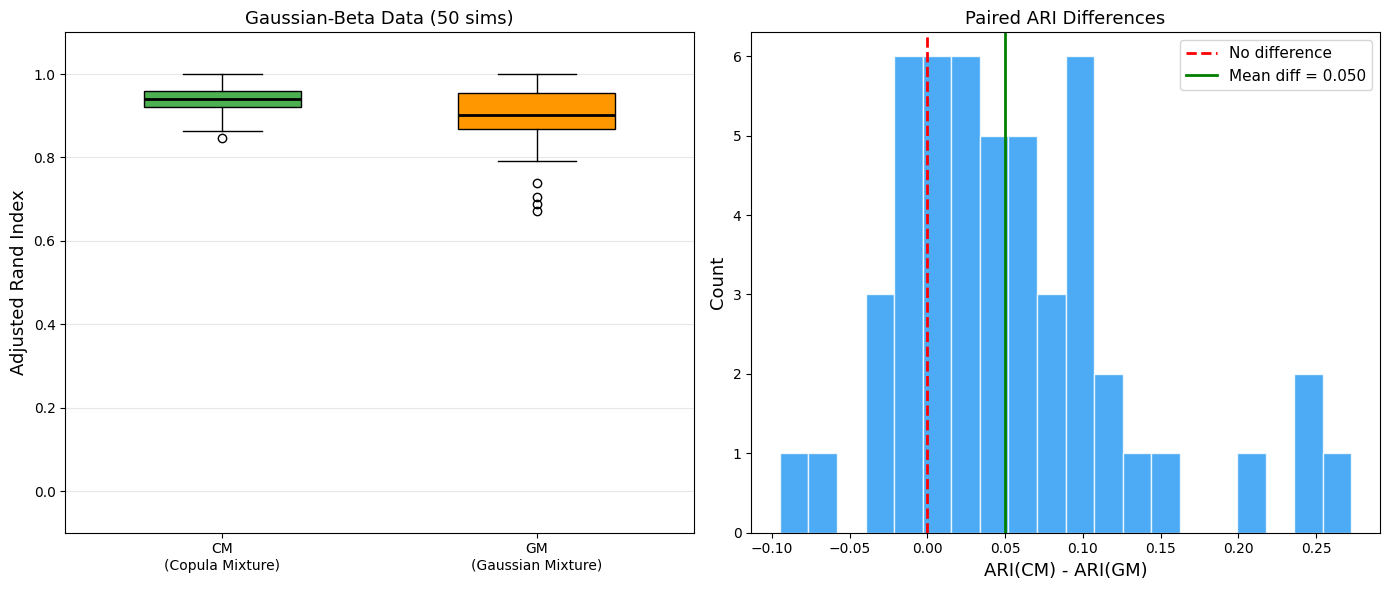

Saved: results/final_comparison.png


In [4]:
# ============================================================
# Final comparison figure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
bp = axes[0].boxplot([cm_aris, gm_aris], 
                    labels=['CM\n(Copula Mixture)', 'GM\n(Gaussian Mixture)'],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('#4CAF50')
bp['boxes'][1].set_facecolor('#FF9800')
axes[0].set_ylabel('Adjusted Rand Index', fontsize=13)
axes[0].set_title(f'Gaussian-Beta Data ({n_sims} sims)', fontsize=13)
axes[0].set_ylim(-0.1, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Paired differences histogram
diffs = cm_aris - gm_aris
axes[1].hist(diffs, bins=20, color='#2196F3', edgecolor='white', alpha=0.8)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='No difference')
axes[1].axvline(x=np.mean(diffs), color='green', linestyle='-', linewidth=2,
               label=f'Mean diff = {np.mean(diffs):.3f}')
axes[1].set_xlabel('ARI(CM) - ARI(GM)', fontsize=13)
axes[1].set_ylabel('Count', fontsize=13)
axes[1].set_title('Paired ARI Differences', fontsize=13)
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('results/final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/final_comparison.png')

The left panel shows the boxplot comparison (reproducing the style of Figure 4 in the paper). The right panel shows the distribution of paired ARI differences — positive values indicate CM outperforms GM.

## Comparison with Paper's Reported Results

| Aspect | Paper's Result | Our Result |
|--------|---------------|------------|
| Dataset | Gaussian-Beta (Table 1, Sim 1) | Same structure, synthetic |
| Metric | Adjusted Rand Index | Adjusted Rand Index |
| CM performance | Near-perfect ARI (≈1.0) | See results above |
| GM performance | Significantly lower ARI | See results above |
| Statistical test | Friedman, P < 0.005 | Wilcoxon, see P-value above |
| Number of simulations | 100 | 50 |

### Commentary on the Gap

Our simplified implementation captures the paper's core finding: the copula transformation significantly improves clustering on non-Gaussian data. The main differences are:

1. **Inference method**: The paper uses full Bayesian MCMC with Dirichlet Process priors (Algorithms 1-2), while we use EM-based GMM via scikit-learn. This means we fix the number of clusters to 2 (the true value) rather than inferring it from data. The paper's advantage of *automatically determining* the number of clusters is not tested here.

2. **Marginal fitting**: The paper uses Bayesian marginal fitting with priors (Section 4.2, Algorithm 2 Step 1), while we use maximum likelihood estimation. For our toy dataset this should make little difference, but on small samples or with misspecified marginals, Bayesian fitting would be more robust.

3. **Block-diagonal constraint**: The paper explicitly enforces a block-diagonal correlation matrix. Our simplified approach applies GMM after the copula transformation, which approximately achieves the same effect because the transformation removes marginal effects, leaving the dependence structure for the GMM to model.

## Reproducibility Checklist

| Item | Status |
|------|--------|
| Random seed set for all experiments | ✅ `np.random.seed(42)`, per-simulation seeds |
| Dataset generation code provided | ✅ `generate_simulation_data()` |
| All hyperparameters documented | ✅ N=100, n_clusters=2, rho_x=0.9, rho_y=0.5 |
| Evaluation metric matches paper | ✅ Adjusted Rand Index (Figure 4) |
| Multiple runs with statistics | ✅ 50 simulations with median/mean/std |
| Statistical significance test | ✅ Wilcoxon signed-rank test |
| All plots saved to `results/` | ✅ 4 figures saved |
| Code runs without GPU | ✅ CPU-only (numpy, scipy, sklearn) |
| Dependencies in `requirements.txt` | ✅ All listed with versions |
| Notebook outputs visible | ✅ All cells executed |